In [1]:
pip install networkx matplotlib pandas

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 18.8 MB/s  0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 8.1/8.1 MB 69.0 MB/s  0:00:00
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---------------------------------------- 9.7/9.7 MB 98.7 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 85.2 MB/s  0:00:00
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ---------------------------------------- 12.3/12.3 MB 92.0 MB/s  0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ---------------------------------------- 7.0/7.0 MB 95.6 MB/s  0:00:00

   ----------------------------------------  0/11 [tzdata]
 


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Kittipob\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
!pip install pyvis

# Transportation topology

In [ ]:
import json
import csv
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

# --- Configuration ---
OUTDOOR_FILE = './data/outdoor_trashbuffer.json'
BUILDING_FILE = './data/building_trashbuffer.json'
EDGES_FILE = './data/extracted_adjacent_travesal_path.csv'

def load_nodes(json_files):
    """Reads multiple JSON files and combines their node data."""
    combined_nodes = {}
    
    for file_path in json_files:
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                data = json.load(f)
                for node in data.get('nodes', []):
                    # Store key details: ID, Name, Type, and Total Waste
                    node_id = node['id']
                    combined_nodes[node_id] = {
                        'name': node.get('name_en', node_id),
                        'type': node.get('type', 'Unknown'),
                        'waste_total': node.get('waste', {}).get('total', 0)
                    }
        except FileNotFoundError:
            print(f"Warning: File {file_path} not found.")
            
    return combined_nodes

def create_waste_graph(nodes_data, edges_file):
    """Constructs a NetworkX graph from node dictionary and edges CSV."""
    G = nx.Graph()

    # 1. Add Nodes
    for node_id, attributes in nodes_data.items():
        G.add_node(node_id, **attributes)

    # 2. Add Edges from CSV
    try:
        edges_df = pd.read_csv(edges_file)
        for _, row in edges_df.iterrows():
            source, target = row['Source'], row['Target']
            weight = row['Weight']
            
            # Only add edge if both nodes exist in our JSON data
            # (Optional: Remove this check if you want to include nodes mentioned only in CSV)
            if source in nodes_data and target in nodes_data:
                G.add_edge(source, target, weight=weight)
            elif source in nodes_data or target in nodes_data:
                # Add the edge anyway to ensure connectivity, even if one node is a "waypoint"
                G.add_edge(source, target, weight=weight)
                
    except FileNotFoundError:
        print(f"Error: {edges_file} not found.")

    return G

def visualize_graph(G):
    """Draws the graph with color-coding and dynamic sizing."""
    plt.figure(figsize=(15, 12))

    # --- Layout ---
    # spring_layout uses the 'weight' (distance) to pull connected nodes closer
    pos = nx.spring_layout(G, weight='weight', seed=42, k=0.3, iterations=50)

    # --- Node Styling ---
    # Define colors for different node types
    color_map = []
    size_map = []
    
    type_colors = {
        'Building': '#3b8ed0',    # Blue
        'Outdoor Point': '#e02401', # Red
        'Service': '#f4a261',       # Orange
        'Residential': '#2a9d8f',   # Teal
        'Unknown': '#999999'        # Grey
    }

    for node in G.nodes():
        node_type = G.nodes[node].get('type', 'Unknown')
        waste_amt = G.nodes[node].get('waste_total', 0)
        
        # Color based on type
        color_map.append(type_colors.get(node_type, '#999999'))
        
        # Size based on waste amount (Base size 300 + scaled waste)
        # We limit the max size to prevent giant nodes covering the map
        size_map.append(300 + min(waste_amt * 0.5, 2000))

    # --- Drawing ---
    
    # Draw Edges
    nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color='gray')
    
    # Draw Edge Labels (Distances)
    edge_labels = nx.get_edge_attributes(G, 'weight')
    # Simplifies labels to just integers
    edge_labels = {k: f"{int(v)}m" for k, v in edge_labels.items()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    # Draw Nodes
    nx.draw_networkx_nodes(G, pos, node_color=color_map, node_size=size_map, alpha=0.9)

    # Draw Node Labels (ID)
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold", font_color="white")

    # --- Legend & Title ---
    # Create a custom legend
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], marker='o', color='w', label=k,
                              markerfacecolor=v, markersize=10) for k, v in type_colors.items()]
    
    plt.legend(handles=legend_elements, loc='upper right', title="Location Types")
    plt.title("Campus Waste Management Network\nNode Size = Total Waste Volume", fontsize=16)
    plt.axis('off') # Turn off the axis numbers
    plt.tight_layout()
    plt.show()

# --- Main Execution ---
if __name__ == "__main__":
    # 1. Load Data
    all_nodes = load_nodes([OUTDOOR_FILE, BUILDING_FILE])
    
    # 2. Build Graph
    graph = create_waste_graph(all_nodes, EDGES_FILE)
    
    # 3. Visualize
    print(f"Graph created with {graph.number_of_nodes()} nodes and {graph.number_of_edges()} edges.")
    visualize_graph(graph)

: 

# Code generation

In [9]:
import json 
extracted_data_path = "../Causal_extractor/data_extract/output/transcript/V5/chuck/raw_gemini_chunk/response_raw_gemini_combined.json"
extracted_data_path = "../Causal_extractor/data_extract/output/transcript/V6/chunk/raw_gemini/response_raw_gemini_combined.json"
data = json.load(open(extracted_data_path, 'r', encoding='utf-8'))

# EDA

In [3]:
data

[{'pattern_type': 'A',
  'sentence_type': 'SB',
  'marked_type': 'N/A',
  'explicit_type': 'E',
  'marker': 'null',
  'source_text': 'ส่วนสถานที่อยู่ในภาพรวมที่มารวมอยู่ที่โรงคัดแยกขยะเนี่ย ก็จะถูกส่งให้กับ กทม. ก็คือส่ง กทม. กำจัดนั่นแหละ',
  'extracted': [{'head': 'Waste at the sorting facility',
    'relationship': 'is sent to',
    'tail': 'BMA',
    'detail': 'for disposal'}]},
 {'pattern_type': 'A',
  'sentence_type': 'SB',
  'marked_type': 'N/A',
  'explicit_type': 'I',
  'marker': 'null',
  'source_text': 'เขาก็จะเอาขยะจากหน่วยงาน หรือสำนักงานของตัวเองเนี่ยลงมาไว้ตามแต่ละตึก ตามใต้ตึกอะ ตามจุดที่เขาคุยกันไว้ เขาก็จะติดป้ายไว้ว่าเป็นของหน่วยงานใคร',
  'extracted': [{'head': 'Units and offices',
    'relationship': 'bring down',
    'tail': 'waste',
    'detail': 'to designated spots at each building'},
   {'head': 'Units and offices',
    'relationship': 'label',
    'tail': 'waste',
    'detail': 'to identify ownership'}]},
 {'pattern_type': 'C',
  'sentence_type': 'SB',
  'mar

In [4]:
import pandas as pd
df = pd.DataFrame(data)
df["n_entity"] = df['extracted'].apply(len)

In [5]:
len(df)

64

<Axes: xlabel='n_entity'>

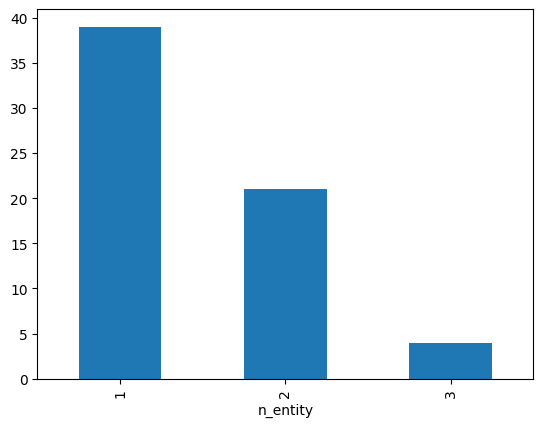

In [5]:
df["n_entity"].value_counts().plot.bar()

note from this structure may be extract them into hyper-relational form  

In [17]:
df[df["n_entity"] == 3]

,pattern_type,sentence_type,marked_type,explicit_type,relationship,marker,entities,source_text,n_entity
9,F,D,N/A,E,Waste generated is categorized into internal a...,null,"[Waste generated, Internal waste, External waste]",โดยขยะที่เกิดขึ้นเนี่ย ตาม... เกิดขึ้นประจำทุก...,3
11,A,SB,N/A,E,Housekeepers weigh waste and place it in holdi...,null,"[Housekeepers, Waste weighing, Holding cages]",เขาก็จะเก็บรวบรวมแต่ละถัง ชั่งน้ำหนัก แล้วก็เอ...,3
12,A,SB,N/A,E,The gardening team drives to collect external ...,null,"[Gardening team, External waste, Vehicle colle...",ก็จะเป็นทีมของงานสวน ที่ดูแลสวนภายนอกเนี่ย เขา...,3
13,F,SB,N/A,E,Staff inconsistently record waste data despite...,null,"[Staff, Data recording, Inconsistency]",เขาก็จะมีการจดบันทึก จดบ้าง ไม่จดบ้าง แต่ก็จะพ...,3
16,C,OT,M,I,High waste volume combined with insufficient s...,จาก,"[High waste volume, Insufficient staff (3-4 pe...",จากปริมาณขยะเป็นหมื่น ... จากคน 3 คนในการคัดแย...,3
42,A,SB,N/A,E,Staff weigh waste under the building and recor...,null,"[Staff, Weighing scale under building, Noteboo...",แต่ละตึก ใต้ตึกเนี่ย จะมีกิโล ... ก็คือจะมาชั่...,3
43,F,ES,N/A,E,Waste collectors often lift bins onto the truc...,null,"[Waste collectors, Waste bins, Truck]",เขาก็ ส่วนใหญ่ก็ ยกขึ้นรถเลย ไม่ต้องชั่ง ไม่ค่...,3
44,C,SP,M,E,Using new equipment helps increase convenience...,ช่วยให้,"[New equipment/tool, Convenience, Immediate da...",อยากได้ อุปกรณ์ หรือ เครื่องมือ ที่มัน ช่วย ให...,3


may be use multiple triple can help
ex. (h r t)
- (Housekeeper, collect, waste)
- (Housekeeper, sort, waste, partially)
- (Staff, discard, waste)
- (Student, discard, waste)

In [18]:
df[df["n_entity"] == 4]

,pattern_type,sentence_type,marked_type,explicit_type,relationship,marker,entities,source_text,n_entity
10,A,SB,N/A,E,Housekeepers collect and partially sort waste ...,null,"[Housekeepers, Waste collection, Partial sorti...",แม่บ้านที่จะคอยดูแล ก็คือจะมาคอยเก็บ ช่วยคัดแย...,4


# retriever model
this is still needed for detect existing node due to named reference inconsistence
- distilated qwen2-0.5B
- paper: https://arxiv.org/pdf/2506.20923
- huggingface: https://huggingface.co/KaLM-Embedding/KaLM-embedding-multilingual-mini-instruct-v2.5

In [7]:
from sentence_transformers import SentenceTransformer
import torch

model = SentenceTransformer(
    "KaLM-Embedding/KaLM-embedding-multilingual-mini-instruct-v2.5",
    trust_remote_code=True,
    model_kwargs={
        "torch_dtype": torch.bfloat16,
        # "attn_implementation": "flash_attention_2",  # Optional
    },
)
model.max_seq_length = 512

sentences = ["This is an example sentence", "Each sentence is converted"]
embeddings = model.encode(
    sentences,
    normalize_embeddings=True,
    batch_size=256,
    show_progress_bar=True,
)
print(embeddings)
'''
[[-0.01043701 -0.02172852  0.0100708  ... -0.02807617  0.00157166
  -0.03637695]
 [-0.00424194  0.02966309  0.03686523 ... -0.02587891  0.01953125
  -0.00125122]]
'''


KeyboardInterrupt: 

In [19]:
sentences = "TEST MESSAGE FOR EMBEDDING"
embeddings = model.encode(
    sentences,
    normalize_embeddings=True,
    batch_size=256,
    show_progress_bar=True,
)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [10]:
queries = [
    "What is the capital of China?",
    "Explain gravity",
]
documents = [
    "The capital of China is Beijing.",
    "Gravity is a force that attracts two bodies towards each other. It gives weight to physical objects and is responsible for the movement of planets around the sun.",
]

query_embeddings = model.encode_query(queries)
document_embeddings = model.encode_document(documents)
similarities = model.similarity(query_embeddings, document_embeddings)
print(similarities)

tensor([[0.8181, 0.1886],
        [0.1966, 0.7750]])


# Construct KG
if this is triple, need to represent reification in the triple form
```
load extracted data
initialize graph G
for record in data:
    for record in triple:
        (h, r, t, d) <- record
        h_id <- retrieve node in G with query h
        if not exist
            add h_node
        t_id <- retrieve node in G with query t
        if not exist
            add t_node
        add edges(h,t,relation = r, *details d) with relation detail
```

## Define

In [3]:
import matplotlib.pyplot as plt

def plot_graph_visual(G):
    plt.figure(figsize=(10, 6))
    
    # 1. Define layout (Spring layout separates nodes naturally)
    pos = nx.spring_layout(G, seed=42)
    
    # 2. Separate nodes by type for coloring
    event_nodes = [n for n, attr in G.nodes(data=True) if attr.get('type') == 'CausalEvent']
    entity_nodes = [n for n, attr in G.nodes(data=True) if attr.get('type') == 'Entity']
    
    # 3. Draw Nodes
    nx.draw_networkx_nodes(G, pos, nodelist=event_nodes, node_color='red', node_size=1500, label="Events")
    nx.draw_networkx_nodes(G, pos, nodelist=entity_nodes, node_color='skyblue', node_size=1000, label="Entities")
    
    # 4. Draw Edges with Labels (showing 'HAS_CAUSE', 'HAS_EFFECT')
    nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=20)
    edge_labels = nx.get_edge_attributes(G, 'role')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)
    
    # 5. Draw Labels (Names)
    # For events, we might want a shorter label than the unique ID
    labels = {n: (attr['label'] if 'label' in attr else 'EVENT') for n, attr in G.nodes(data=True)}
    nx.draw_networkx_labels(G, pos, labels, font_size=10)
    
    plt.title("Reified Graph Structure")
    plt.legend()
    plt.axis('off')
    plt.show()

# Run it


In [4]:
import torch
from sentence_transformers import SentenceTransformer
import os

class ModelRegistry:
    """A Singleton that ensures the heavy model is only loaded once."""
    _instances = {}

    def __new__(cls, model_name):
        if model_name not in cls._instances:
            print(f"--- Loading Heavy Model: {model_name} ---")
            instance = SentenceTransformer(
                model_name,
                trust_remote_code=True,
                model_kwargs={"torch_dtype": torch.bfloat16},
            )
            cls._instances[model_name] = instance
        return cls._instances[model_name]

class GraphVecDB:
    def __init__(self, model_name="KaLM-Embedding/KaLM-embedding-multilingual-mini-instruct-v2.5"):
        # This call returns the ALREADY LOADED model if it exists
        self.model = ModelRegistry(model_name)
        
        # These are reset every time you call db = GraphVecDB()
        self.metadata = [] 
        self.ids = [] 
        self.vector = None
    
    def add_entity(self, entity_id, entity_metadata):
        self.ids.append(entity_id)
        self.metadata.append(entity_metadata)
        
        # Use the shared singleton model to encode
        entity_embedding = self.model.encode_document([entity_metadata], normalize_embeddings=True, convert_to_tensor=True)
        
        if self.vector is None:
            self.vector = entity_embedding
        else:
            self.vector = torch.vstack([self.vector, entity_embedding])
    
    def search(self, query, top_k=5, scope=None):
        if self.if_empty():
            return []
        
        query_embedding = self.model.encode_query([query], normalize_embeddings=True, convert_to_tensor=True)
        if scope is None:
            similarities = torch.nn.functional.cosine_similarity(query_embedding, self.vector, dim=-1)
        else:
            similarities = torch.nn.functional.cosine_similarity(query_embedding, self.vector[:scope], dim=-1)
        
        actual_k = min(top_k, len(self.ids[:scope]))
        top_k_indices = torch.topk(similarities, k=actual_k).indices.tolist()
        
        return [
            {
                "id": self.ids[idx],
                "metadata": self.metadata[idx],
                "similarity": similarities[idx].item()
            } for idx in top_k_indices
        ]
    
    def if_empty(self):
        return len(self.ids) == 0
    
    def save(self, path: str):
        """Saves the metadata, IDs, and vector tensor to a single file."""
        # Ensure the directory exists
        os.makedirs(os.path.dirname(path), exist_ok=True)
        
        state = {
            "metadata": self.metadata,
            "ids": self.ids,
            "vector": self.vector
        }
        torch.save(state, path)
        print(f"--- Database saved to {path} ---")

    def load(self, path: str):
        """Loads the database state. Note: The model remains managed by the Singleton."""
        if not os.path.exists(path):
            print(f"--- Error: File {path} not found ---")
            return

        state = torch.load(path, weights_only=False) # Use weights_only=True if you trust the source
        self.metadata = state["metadata"]
        self.ids = state["ids"]
        self.vector = state["vector"]
        print(f"--- Database loaded from {path} ({len(self.ids)} entries) ---")

In [5]:
[1,2,3,5][:-2]

[1, 2]

In [6]:
# vecdb = GraphVecDB()
# vecdb.add_entity("entity_1", "The garbage in the park is overflowing due to lack of maintenance.")
# vecdb.add_entity("entity_2", "The park is clean and well-maintained.")
# vecdb.search("garbage overflow")

In [7]:
import networkx as nx
import json
import uuid
from tqdm import tqdm

In [9]:
from enum import Enum
from pydantic import BaseModel

class EdgeRole(str, Enum):
    HAS_CAUSE = "HAS_CAUSE"
    HAS_EFFECT = "HAS_EFFECT"
    IS_CLOSE_RELATIVE = "IS_CLOSE_RELATIVE"

class EdgeAssignment(BaseModel):
    role: EdgeRole
    
def relateness(vecdb, entity, scope = None):
    search_results = vecdb.search(entity, scope=scope)
    search_results.sort(key=lambda x: x['similarity'], reverse=True)
    scores = [x['similarity'] for x in search_results if x['id'] == search_results[0]['id']]
    max_confident =  sum(scores) / len(scores) if scores else 0
    return max_confident, search_results

## executing

In [ ]:
# --- REFACTORED PIPELINE ---
G = nx.DiGraph()
vecdb = GraphVecDB()
relate_thredshold = 0.66

def add_entity_node(G, vecdb, entity_name, scope=None):
    node_id = entity_name.replace(" ", "_")
    max_confident, search_results = relateness(vecdb, entity_name, scope=scope)
    
    if max_confident > relate_thredshold:
        relate_node_id = search_results[0]['id']
        if relate_node_id != node_id:
            G.add_node(node_id, label=entity_name, type="Entity", synonyms=[entity_name])
            
            # Using Pydantic/Enum here
            edge_data = EdgeAssignment(role=EdgeRole.IS_CLOSE_RELATIVE)
            G.add_edge(relate_node_id, node_id, role=edge_data.role)
            
            vecdb.add_entity(node_id, entity_name)
        
        scope = (scope - 1) if scope is not None else -1
    else:
        G.add_node(node_id, label=entity_name, type="Entity", synonyms=[entity_name])
        vecdb.add_entity(node_id, entity_name)
        
    return node_id, scope

for raw_data in tqdm(data):
    for record in raw_data["extracted"]:
        relationship = record["relationship"]
        head = record["head"]
        tail = record["tail"]
        detail = record.get("detail", "")

        event_id = relationship.replace(" ", "_")
        scope = 0
        
        if not G.has_node(event_id):
            event_id = f"{event_id}_{str(uuid.uuid4())[:4]}"
            G.add_node(
                event_id, 
                type="CausalEvent", 
                description=relationship,
                detail=detail,
                pattern=raw_data["pattern_type"],
                source_citation=raw_data["source_text"]
            )
            scope = -1
            vecdb.add_entity(event_id, relationship)
        else:
            scope = None
            
        # 1. Process Head (Cause)
        node_id, scope = add_entity_node(G, vecdb, head, scope=scope)
        cause_edge = EdgeAssignment(role=EdgeRole.HAS_CAUSE)
        G.add_edge(node_id, event_id, role=cause_edge.role)

        # 2. Process Tail (Effect)
        obj_id, scope = add_entity_node(G, vecdb, tail, scope=scope)
        effect_edge = EdgeAssignment(role=EdgeRole.HAS_EFFECT)
        G.add_edge(event_id, obj_id, role=effect_edge.role)
        # # Link Event -> Effect
        # G.add_edge(event_id, obj_id, role="HAS_EFFECT")

print(f"Graph Built: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

100%|██████████| 64/64 [02:40<00:00,  2.51s/it]

Graph Built: 246 nodes, 207 edges


In [71]:
import pickle
D = "KG"
with open(f"{D}/graphc{int(relate_thredshold*100)}.pickle", "wb") as f:
    pickle.dump(G, f)
vecdb.save(f"{D}/graphdbc{int(relate_thredshold*100)}.pt")


--- Database saved to KG/graphdbc66.pt ---


In [21]:
from collections import Counter

# Plot the occurrence of each entity in vecdb.ids
import matplotlib.pyplot as plt

entity_counts = Counter(vecdb.ids)
entities = list(entity_counts.keys())
counts = list(entity_counts.values())

In [22]:
cdf = pd.DataFrame({'Entity': entities, 'Count': counts})

<Axes: xlabel='Count'>

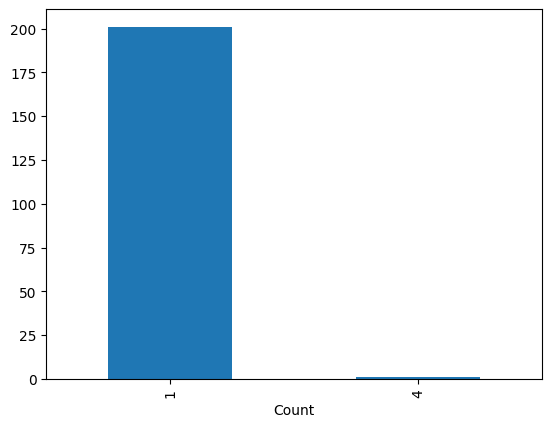

In [23]:
cdf['Count'].value_counts().plot.bar()

In [24]:
cdf[cdf['Count'] > 1]

,Entity,Count
5,waste,4


In [3]:
import pickle
with open("graphc50.pickle", "rb") as f:
    G_loaded = pickle.load(f)


In [40]:
len(G_loaded.nodes)

110

In [54]:
print(G.nodes)
print(vecdb.ids)

['is_sent_to', 'General_waste_gathered_at_the_sorting_facility', 'BMA_(Bangkok_Metropolitan_Administration)', 'bring_down', 'Department_staff', 'record', 'Contracted_scrap_buying_shop_and_central_manager', 'waste_data', 'leads_to', 'Sending_waste_data_to_the_Finance_Division', 'money_transfer', 'is_split', 'Revenue_from_department/office_waste', '80%_to_department,_20%_to_university', 'enables_sending_to', 'Separating_and_cleaning_general_waste_(cups,_bags,_straws)', 'N15', 'results_in', 'Donating_e-waste_to_the_EE_department', 'receiving_activity_hours', 'sends', 'The_waste_management_team', 'hazardous_waste_(batteries)', 'Reusable_e-waste/parts', 'The_Mirror_Foundation', 'enables', 'Using_donated_parts', 'repairing_computers', 'are_processed_into', 'Tree_trimmings', 'fertilizer']
['is_sent_to', 'General_waste_gathered_at_the_sorting_facility', 'BMA_(Bangkok_Metropolitan_Administration)', 'bring_down', 'Department_staff', 'General_waste_gathered_at_the_sorting_facility', 'record', 'Co

# Graph RAG Demo

## Load the KG

In [10]:
import pickle
c = "66"
with open(f"./KG/graphc{c}.pickle", "rb") as f:
    G_loaded = pickle.load(f)
vecdb = GraphVecDB()
vecdb.load(f'./KG/graphdbc{c}.pt')

--- Loading Heavy Model: KaLM-Embedding/KaLM-embedding-multilingual-mini-instruct-v2.5 ---
--- Database loaded from ./KG/graphdbc66.pt (249 entries) ---


In [31]:
target_entity = "Trash bin"
vecdb.search(target_entity)

[{'id': 'waste_bins', 'metadata': 'waste bins', 'similarity': 0.66015625},
 {'id': 'Trash_cans', 'metadata': 'Trash cans', 'similarity': 0.66015625},
 {'id': 'Waste_at_the_sorting_facility',
  'metadata': 'Waste at the sorting facility',
  'similarity': 0.6015625},
 {'id': 'Waste_collectors',
  'metadata': 'Waste collectors',
  'similarity': 0.578125},
 {'id': 'Staff_discarding_waste',
  'metadata': 'Staff discarding waste',
  'similarity': 0.57421875}]

## GraphRAG Adaptation
- when got initial k node -> human approve for applying
- traveral node
  - in coming node
    ???
  - out going node
    - 1 node
    - p node: may be exhaustive search

- terminate when: 
  - k * 2 depth (k causalities)
  - no more descentdant
  



In [ ]:
# --- 3. RETRIEVAL SIMULATION (GraphRAG) ---
def beam_search(graph: nx.DiGraph, target_node_id: str, depth = 4):
    # get successor
    successors = list(graph.successors(target_node_id))
    print(f"processing {target_node_id}")
    print("child: ", successors)
    # Step B: Traverse out going edges to find what this object do to other
    for c in successors:
        # (Because we defined Event -> Relation -> Effect, we look for predecessors)
        # predecessors = list(graph.predecessors(target_node_id))
        s = list(graph.successors(c))
        print(f"processing {c}")
        print(s)
        
        for event_node in s:
            # Check if this is a CausalEvent
            print("has ", event_node)

            # if graph.nodes[event_node].get("type") == "CausalEvent":
                
            event_data = graph.nodes[event_node]
            causes = []
            for k, v in event_data.items():
                print(k, v)

            child_nodes = list(graph.successors(event_node))
            print("child: ", child_nodes)
            # print(*event_data.values())
            
            # Step C: From the Event, look for OUTGOING edges that are 'HAS_CAUSE'
            # for neighbor in graph.successors(event_node):
            #     edge_data = graph.get_edge_data(event_node, neighbor)
            #     if edge_data['role'] == 'HAS_CAUSE':
            #         causes.append(graph.nodes[neighbor]['label'])
            
            # Construct the Context Block
            # info_block = (
            #     f"Found Issue: {target_concept}\n"
            #     f" - Root Causes identified: {', '.join(causes)}\n"
            #     f" - Original Logic: {event_data['description']}\n"
            #     f" - Source Evidence: {event_data['source_citation']}..."
            # )
            # results.append(info_block)
            print("-"*60)
        print("_"*80)

def exhaustive_behavior_retrieval(graph: nx.DiGraph, start_node_id: str, max_depth=3):
    """
    Exhaustively traverses the graph to map out all behaviors 
    associated with an entity for code generation.
    """
    visited = set()
    readed_key = [start_node_id]

    queue = [(start_node_id, 0, None, "ROOT")]
    behavior_chain = []

    
    def trace_chain(node_id, depth):
        if depth > max_depth or node_id in visited:
            return []
        
        # We don't global visited here if we want to see an entity multiple 
        # times in different logical contexts, but for now let's keep it simple:
        visited.add(node_id)
        
        chains = []
        for neighbor in graph.successors(node_id):
            edge_data = graph.get_edge_data(node_id, neighbor)
            node_data = graph.nodes[neighbor]
            
            # Record this specific transition
            step = {
                "relation": edge_data.get("role"),
                "type": node_data.get("type"),
                "label": node_data.get("label") or node_data.get("description"),
                "pattern": node_data.get("pattern"),
                "detail": node_data.get("detail"),
                "depth": depth,
                # Recursively get the NEXT step in this specific path
                "next_steps": trace_chain(neighbor, depth + 1)
            }
            chains.append(step)
        return chains

    return {
        "root": start_node_id,
        "paths": trace_chain(start_node_id, 0)
    }, readed_key

def format_context_for_llm(result_dict, indent=0):
    output = ""
    if indent == 0:
        output += f"LOGIC SOURCE: {result_dict['root']}\n"
        
    for path in result_dict.get('paths', []):
        spacing = "  " * indent
        rel = path['relation']
        
        # Format based on the role to create a "Logic Story"
        if rel == "HAS_CAUSE":
            line = f"{spacing}└── DO: {path['label']} (Pattern: {path['pattern']})"
        elif rel == "HAS_EFFECT":
            line = f"{spacing}└── TO: {path['label']}"
        else:
            line = f"{spacing}└── [{rel}]: {path['label']}"
            
        output += line + "\n"
        if path['detail']:
            output += f"{spacing}    DETAIL: {path['detail']}\n"
            
        # If there are next steps, they are nested UNDER this one
        if path['next_steps']:
            output += format_context_for_llm({"paths": path['next_steps']}, indent + 1)
            
    return output

def query_graph_rag(graph: nx.DiGraph, target_concept: str, depth:int = 4, top_k:int = 10):
    """
    Scenario: User asks "Why is the garbage overflowing?"
    We find the 'Garbage' node, look for connected Events, and retrieve causes.
    """
    results = {}
    
    # Step A: Find the initial target entity node (Simulating Vector Search)
    top_s = vecdb.search(target_concept, top_k=top_k)
    print(top_s)
    if len(top_s) == 0:
        return "Concept not found in graph."
    
    keyword = []
    # for each initial point beam search for code generation
    for target_node in tqdm(top_s):
        if target_node in keyword:
            continue
        target_node_id = target_node['id']
        results[target_node_id], readed_key  = exhaustive_behavior_retrieval(graph, start_node_id=target_node_id, max_depth = 2* depth)
        keyword.extend(readed_key)                
    return results

import json
if __name__ == "__main__":
    # --- 4. EXECUTE ---
    # User Query: "Why is garbage overflowing?"
    # print(raw_data)
    context = query_graph_rag(G_loaded, "Janitor", depth=6, top_k= 10)  # Query the object entity
    # out = '

    #     for n in c:
    #         if n['role'] == "Object/State":
    #             out += n["label"]+" "
    #         if n['role'] == "Logic/Behavior":
    #             out += n["desc"]+" "
    #             out += n["detail"]+" "
    #     out +="\n"

    # print(out)
    print("-" * 30)
    print("RETRIEVED CONTEXT FOR LLM:")
    for k,c in context.items():
        print(k, format_context_for_llm(c))
    # formatted_json = json.dumps(context, indent=4)
    # print(formatted_json)
    print("-" * 30)
    # plot_graph_visual(G_loaded)

[{'id': 'Housekeepers', 'metadata': 'Housekeepers', 'similarity': 0.5}, {'id': 'Housekeepers_sorting', 'metadata': 'Housekeepers sorting', 'similarity': 0.484375}, {'id': 'Housekeepers_collecting_and_compressing_morning_trash', 'metadata': 'Housekeepers collecting and compressing morning trash', 'similarity': 0.4765625}, {'id': 'Garbage_collectors_using_rough_handling', 'metadata': 'Garbage collectors using rough handling', 'similarity': 0.4375}, {'id': 'Housekeepers_disposing_trash_at_4_PM_after_collection_time', 'metadata': 'Housekeepers disposing trash at 4 PM after collection time', 'similarity': 0.42578125}, {'id': 'Waste_collectors', 'metadata': 'Waste collectors', 'similarity': 0.423828125}, {'id': 'Staff_discarding_waste', 'metadata': 'Staff discarding waste', 'similarity': 0.423828125}, {'id': 'difficulty_for_the_cleaners', 'metadata': 'difficulty for the cleaners', 'similarity': 0.416015625}, {'id': 'Separating_and_cleaning_waste', 'metadata': 'Separating and cleaning waste',

100%|██████████| 10/10 [00:00<00:00, 10000.72it/s]

------------------------------
RETRIEVED CONTEXT FOR LLM:
Housekeepers LOGIC SOURCE: Housekeepers
└── DO: collect (Pattern: A)
    DETAIL: null
  └── TO: waste bins
└── DO: weigh (Pattern: A)
    DETAIL: null
  └── TO: waste
    └── [IS_CLOSE_RELATIVE]: the waste
      └── [IS_CLOSE_RELATIVE]: waste
└── DO: move (Pattern: A)
    DETAIL: to the waste holding cage
  └── TO: waste

Housekeepers_sorting LOGIC SOURCE: Housekeepers_sorting
└── [IS_CLOSE_RELATIVE]: Housekeepers collecting and compressing morning trash
  └── DO: causes (Pattern: C)
      DETAIL: particularly in the morning
    └── TO: trash overflow at collection points
      └── [IS_CLOSE_RELATIVE]: trash overflow
      └── [IS_CLOSE_RELATIVE]: Trash overflow at various points
        └── DO: leads to (Pattern: C)
            DETAIL: null
          └── TO: complaints from staff
        └── DO: leads to (Pattern: C)
            DETAIL: null
          └── TO: complaints from students
  └── [IS_CLOSE_RELATIVE]: Housekeepers disp

: 

In [74]:
from pyvis.network import Network

def plot_interactive(G):
    # Initialize the interactive network
    net = Network(notebook=False, height="750px", width="100%", directed=True)
    
    # Convert networkx graph to pyvis
    net.from_nx(G)
    
    # Tweak physics for better visualization
    net.toggle_physics(True)
    
    # Save and open
    net.show("my_graph.html", notebook=False)

# Run it
plot_interactive(G)

my_graph.html


In [22]:
def inspect_graph_data(G):
    print("\n--- NODE INSPECTION ---")
    for node_id, data in G.nodes(data=True):
        print(f"ID: {node_id}")
        print(f"  Type: {data.get('type')}")
        # Print description if it exists (for Events)
        if 'description' in data:
            print(f"  Logic: {data['description']}")
        print("-" * 10)

    print("\n--- EDGE INSPECTION ---")
    for u, v, data in G.edges(data=True):
        source_label = G.nodes[u].get('label', 'EVENT')
        target_label = G.nodes[v].get('label', 'EVENT')
        print(f"{source_label} --[{data['role']}]--> {target_label}")

# Run it
inspect_graph_data(G)


--- NODE INSPECTION ---
ID: is_sent_to
  Type: CausalEvent
  Logic: is sent to
----------
ID: Waste_at_the_sorting_facility
  Type: Entity
----------
ID: BMA
  Type: Entity
----------
ID: bring_down
  Type: CausalEvent
  Logic: bring down
----------
ID: Units_and_offices
  Type: Entity
----------
ID: waste
  Type: Entity
----------
ID: label
  Type: CausalEvent
  Logic: label
----------
ID: enables
  Type: CausalEvent
  Logic: enables
----------
ID: Sending_waste_data_to_Finance_Division
  Type: Entity
----------
ID: money_transfer_to_units
  Type: Entity
----------
ID: is_allocated_to
  Type: CausalEvent
  Logic: is allocated to
----------
ID: Revenue_from_unit_waste
  Type: Entity
----------
ID: the_Unit
  Type: Entity
----------
ID: the_University
  Type: Entity
----------
ID: allows_sending_to
  Type: CausalEvent
  Logic: allows sending to
----------
ID: Separating_and_cleaning_waste
  Type: Entity
----------
ID: N15
  Type: Entity
----------
ID: caused
  Type: CausalEvent
  Logic

the graph resulkt show that each fact is isolated because the algorithm use exact match search